In [2]:
!rm -rf /content/mccain-internship
%cd /content
!git clone https://github.com/PushkargithubCSE/mccain-internship.git
%cd mccain-internship/week-3/potato-finetuning
!pwd
!ls -la data/raw/images/train/

/content
Cloning into 'mccain-internship'...
remote: Enumerating objects: 580, done.
remote: Counting objects: 100% (580/580), done.
remote: Compressing objects: 100% (423/423), done.
remote: Total 580 (delta 152), reused 520 (delta 98), pack-reused 0 (from 0)
Receiving objects: 100% (580/580), 25.11 MiB | 29.76 MiB/s, done.
Resolving deltas: 100% (152/152), done.
/content/mccain-internship/week-3/potato-finetuning
/content/mccain-internship/week-3/potato-finetuning
total 652
drwxr-xr-x 2 root root  4096 Sep  7 11:14 .
drwxr-xr-x 3 root root  4096 Sep  7 11:14 ..
-rw-r--r-- 1 root root 27292 Sep  7 11:14 damage10.png
-rw-r--r-- 1 root root 27824 Sep  7 11:14 damage11.png
-rw-r--r-- 1 root root 28101 Sep  7 11:14 damage12.png
-rw-r--r-- 1 root root 25441 Sep  7 11:14 damage13.png
-rw-r--r-- 1 root root 26496 Sep  7 11:14 damage14.png
-rw-r--r-- 1 root root 29402 Sep  7 11:14 damage15.png
-rw-r--r-- 1 root root 29070 Sep  7 11:14 damage16.png
-rw-r--r-- 1 root root 31540 Sep  7 11:14 dam

In [3]:
import sys
PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"
sys.path.append(f'{PROJECT_PATH}/src')

print(f"Project root: {PROJECT_PATH}")

Project root: /content/mccain-internship/week-3/potato-finetuning


In [4]:
!pip install -q -r /content/mccain-internship/week-3/potato-finetuning/requirements.txt

In [5]:
import torch
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("✗ No GPU — enable in Runtime > Change runtime type")

✓ GPU: Tesla T4


In [6]:
import os
import pandas as pd

PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"
images_dir = f'{PROJECT_PATH}/data/raw/images'
labels_dir = f'{PROJECT_PATH}/data/raw/labels'

for split in ['train', 'val', 'test']:
    os.makedirs(f'{images_dir}/{split}', exist_ok=True)
    os.makedirs(f'{labels_dir}/{split}', exist_ok=True)

your_images = [f for f in os.listdir(f'{images_dir}/train') if f.endswith(('.jpg', '.jpeg', '.png'))]

if not your_images:
    print("ERROR: No images found! Check git pull/clone worked.")
else:
    print(f"✓ Found {len(your_images)} images:")
    for img in sorted(your_images):
        print(f"  - {img}")

    dataset_info = []
    for img_file in your_images:
        class_id, class_name = (1, 'damage') if 'damage' in img_file.lower() else (0, 'not_damage')
        label_file = img_file.split('.')[0] + '.txt'
        with open(f'{labels_dir}/train/{label_file}', 'w') as f:
            f.write('')
        dataset_info.append({'image': img_file, 'class_id': class_id, 'class_name': class_name})

    df = pd.DataFrame(dataset_info)
    df.to_csv(f'{PROJECT_PATH}/data/raw/metadata.csv', index=False)
    print(f"\n✓ metadata.csv created")
    print(df['class_name'].value_counts())

✓ Found 21 images:
  - damage1.png
  - damage10.png
  - damage11.png
  - damage12.png
  - damage13.png
  - damage14.png
  - damage15.png
  - damage16.png
  - damage17.png
  - damage2.png
  - damage3.png
  - damage4.png
  - damage5.png
  - damage6.png
  - damage7.png
  - damage8.png
  - damage9.png
  - not_damage1.png
  - not_damage2.png
  - not_damage3.png
  - not_damage4.png

✓ metadata.csv created
class_name
damage    21
Name: count, dtype: int64


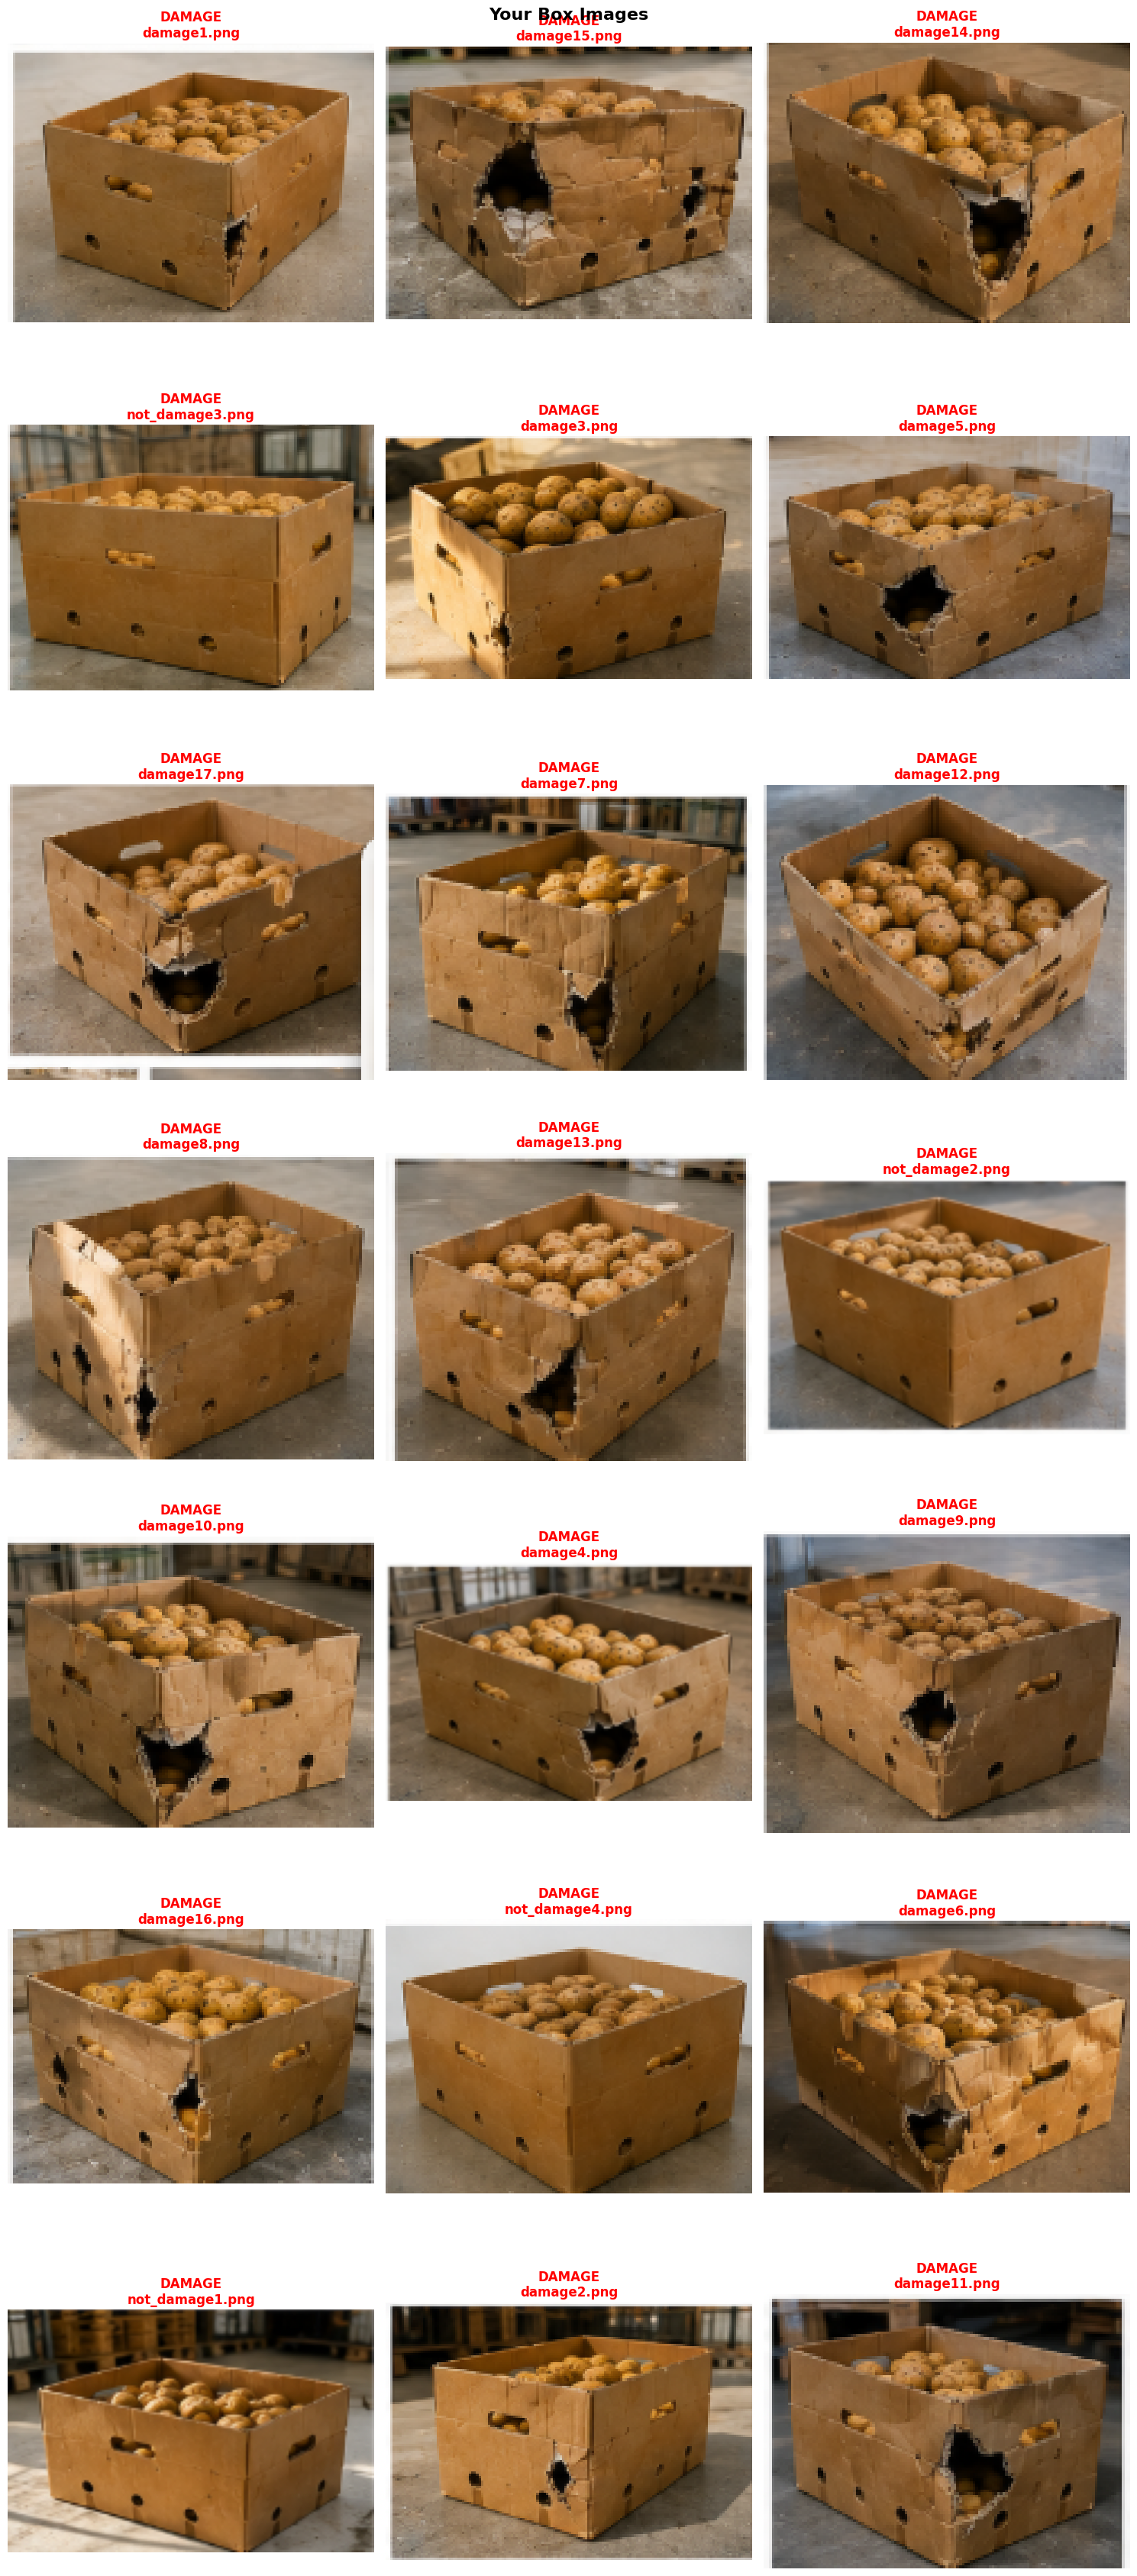

✓ Image overview saved


In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os

PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"
images_dir = f'{PROJECT_PATH}/data/raw/images/train'

df = pd.read_csv(f'{PROJECT_PATH}/data/raw/metadata.csv')

num_images = len(df)
cols = 3
rows = (num_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()

for idx, (_, row) in enumerate(df.iterrows()):
    img_path = f'{images_dir}/{row["image"]}'
    img = Image.open(img_path)

    ax = axes[idx]
    ax.imshow(img)

    title = f"{row['class_name'].upper()}\n{row['image']}"
    color = 'red' if row['class_name'] == 'damage' else 'green'
    ax.set_title(title, fontweight='bold', color=color, fontsize=12)
    ax.axis('off')

for idx in range(num_images, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Your Box Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/data/your_images_overview.png', dpi=100, bbox_inches='tight')
plt.show()


print("✓ Image overview saved")

In [8]:
print(df['class_id'].value_counts())

class_id
1    21
Name: count, dtype: int64


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil
import os

PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"
images_dir = f'{PROJECT_PATH}/data/raw/images'
labels_dir = f'{PROJECT_PATH}/data/raw/labels'
splits_dir = f'{PROJECT_PATH}/data/splits'

# Ensure all needed folders exist
os.makedirs(splits_dir, exist_ok=True)
os.makedirs(f'{images_dir}/val', exist_ok=True)
os.makedirs(f'{images_dir}/test', exist_ok=True)
os.makedirs(f'{labels_dir}/val', exist_ok=True)
os.makedirs(f'{labels_dir}/test', exist_ok=True)

df = pd.read_csv(f'{PROJECT_PATH}/data/raw/metadata.csv')

train, temp = train_test_split(df, test_size=0.4, stratify=df['class_id'], random_state=42)
val, test = train_test_split(temp, test_size=0.5, stratify=temp['class_id'], random_state=42)

print("=" * 60)
print("CREATING SPLITS")
print("=" * 60)
print(f"Train: {len(train)} images")
print(f"Val:   {len(val)} images")
print(f"Test:  {len(test)} images")

for split_name, split_df in [('val', val), ('test', test)]:
    for _, row in split_df.iterrows():
        img_name = row['image']
        label_name = img_name.split('.')[0] + '.txt'

        src_img = f'{images_dir}/train/{img_name}'
        dst_img = f'{images_dir}/{split_name}/{img_name}'
        if os.path.exists(src_img):
            shutil.move(src_img, dst_img)

        src_label = f'{labels_dir}/train/{label_name}'
        dst_label = f'{labels_dir}/{split_name}/{label_name}'
        if os.path.exists(src_label):
            shutil.move(src_label, dst_label)

print("\n✓ Splits created")

train.to_csv(f'{splits_dir}/train.csv', index=False)
val.to_csv(f'{splits_dir}/val.csv', index=False)
test.to_csv(f'{splits_dir}/test.csv', index=False)

print("✓ Split CSVs saved")

CREATING SPLITS
Train: 12 images
Val:   4 images
Test:  5 images

✓ Splits created
✓ Split CSVs saved


In [10]:
PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"

yaml_content = """# YOLO Dataset Configuration
path: /content/mccain-internship/week-3/potato-finetuning/data/raw
train: images/train
val: images/val
test: images/test

nc: 2
names: ['not_damage', 'damage']
"""

with open(f'{PROJECT_PATH}/data/raw/data.yaml', 'w') as f:
    f.write(yaml_content)

print("✓ Created data.yaml")
print(yaml_content)

✓ Created data.yaml
# YOLO Dataset Configuration
path: /content/mccain-internship/week-3/potato-finetuning/data/raw
train: images/train
val: images/val
test: images/test

nc: 2
names: ['not_damage', 'damage']



In [11]:
import os

PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"
images_dir = f'{PROJECT_PATH}/data/raw/images'
labels_dir = f'{PROJECT_PATH}/data/raw/labels'

print("=" * 60)
print("DATASET STRUCTURE VERIFICATION")
print("=" * 60)

for split in ['train', 'val', 'test']:
    imgs = os.listdir(f'{images_dir}/{split}')
    print(f"\n[{split.upper()}] {len(imgs)} images")
    for img in sorted(imgs):
        print(f"  - {img}")

DATASET STRUCTURE VERIFICATION

[TRAIN] 12 images
  - damage1.png
  - damage12.png
  - damage14.png
  - damage15.png
  - damage16.png
  - damage4.png
  - damage5.png
  - damage6.png
  - not_damage1.png
  - not_damage2.png
  - not_damage3.png
  - not_damage4.png

[VAL] 4 images
  - damage10.png
  - damage11.png
  - damage13.png
  - damage2.png

[TEST] 5 images
  - damage17.png
  - damage3.png
  - damage7.png
  - damage8.png
  - damage9.png


In [12]:
import sys
import pandas as pd

PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"
sys.path.append(f'{PROJECT_PATH}/src')

from data.dataset import PotatoDataset
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_df = pd.read_csv(f'{PROJECT_PATH}/data/splits/train.csv')
val_df = pd.read_csv(f'{PROJECT_PATH}/data/splits/val.csv')
test_df = pd.read_csv(f'{PROJECT_PATH}/data/splits/test.csv')

print("=" * 60)
print("✓✓✓ PHASE 1 COMPLETE - YOUR REAL IMAGES LOADED")
print("=" * 60)
print(f"Train: {len(train_df)} images")
print(f"Val:   {len(val_df)} images")
print(f"Test:  {len(test_df)} images")

print("\n✓ Dataset ready for Phase 2: Augmentation")

✓✓✓ PHASE 1 COMPLETE - YOUR REAL IMAGES LOADED
Train: 12 images
Val:   4 images
Test:  5 images

✓ Dataset ready for Phase 2: Augmentation
